In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error 
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')

Maak een Jupyter Notebook waarin je het tabje “AmesHousing” van het bestand AmesHousing.xlsx inleest, als DataFrame in Python. Zorg ervoor dat elke Excel-kolom overeenkomt met een DataFrame-kolom.

In [2]:
dataset = pd.read_excel('AmesHousing.xlsx')
dataset

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story
...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,142500,yes,6,1003,1003.0,7937,1984,1,3,Mitchel,SLvl
2926,2927,131000,yes,5,902,864.0,8885,1983,1,2,Mitchel,1Story
2927,2928,132000,no,5,970,912.0,10441,1992,1,3,Mitchel,SFoyer
2928,2929,170000,yes,5,1389,1389.0,10010,1974,1,2,Mitchel,1Story


Open AmesHousing.xlsx in Excel en lees de inhoud van het tabje “Data Dictionary” goed door. Deze geeft de betekenis weer van elke feature én van de targetvariabele. Zoek uit in welke kolom de targetvariabele staat en maak een top 3 van features waarvan je verwacht dat die het meest voorspellend zijn voor de targetvariabele. Let op: minstens één van deze features moet categorisch zijn! Noteer de gekozen features en het target in je logboek.

In [3]:
'''
De target variable is SalePrice
Mijn gekozen features zijn:
House Style	
Overall Qual
Gr Liv Area
'''

'\nDe target variable is SalePrice\nMijn gekozen features zijn:\nHouse Style\t\nOverall Qual\nGr Liv Area\n'

Prepareer je data in je Jupyter Notebook:
    -One-hot encode je uitgekozen categorische feature(s)
    -Splits de dataset horizontaal én verticaal, zodat er vier “stukken” ontstaan.

In [4]:
dataset = dataset.loc[:,['Overall Qual', 'Year Built', 'House Style', 'Gr Liv Area']]
dataset

,Overall Qual,Year Built,House Style,Gr Liv Area
0,6,1960,1Story,1656
1,5,1961,1Story,896
2,6,1958,1Story,1329
3,7,1968,1Story,2110
4,5,1997,2Story,1629
...,...,...,...,...
2925,6,1984,SLvl,1003
2926,5,1983,1Story,902
2927,5,1992,SFoyer,970
2928,5,1974,1Story,1389


In [5]:
Style = pd.get_dummies(dataset.loc[:, 'House Style'], drop_first=True)
Style

,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl
0,False,True,False,False,False,False,False
1,False,True,False,False,False,False,False
2,False,True,False,False,False,False,False
3,False,True,False,False,False,False,False
4,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...
2925,False,False,False,False,False,False,True
2926,False,True,False,False,False,False,False
2927,False,False,False,False,False,True,False
2928,False,True,False,False,False,False,False


In [6]:
dataset = pd.concat([dataset, Style], axis=1)
dataset = dataset.drop(['House Style'], axis=1)
dataset

,Overall Qual,Year Built,Gr Liv Area,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl
0,6,1960,1656,False,True,False,False,False,False,False
1,5,1961,896,False,True,False,False,False,False,False
2,6,1958,1329,False,True,False,False,False,False,False
3,7,1968,2110,False,True,False,False,False,False,False
4,5,1997,1629,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
2925,6,1984,1003,False,False,False,False,False,False,True
2926,5,1983,902,False,True,False,False,False,False,False
2927,5,1992,970,False,False,False,False,False,True,False
2928,5,1974,1389,False,True,False,False,False,False,False


In [7]:
X = dataset.loc[dataset['Overall Qual'].notna(), :].drop('Overall Qual', axis=1)
Y = dataset.loc[dataset['Overall Qual'].notna(), 'Overall Qual']

#X['Total Bsmt SF'] = X['Total Bsmt SF'].fillna(X['Total Bsmt SF'].median())

In [8]:
X_train, X_test, Y_train,  Y_test = train_test_split(
    X,
    Y,
    test_size=0.15,
    random_state=42

)

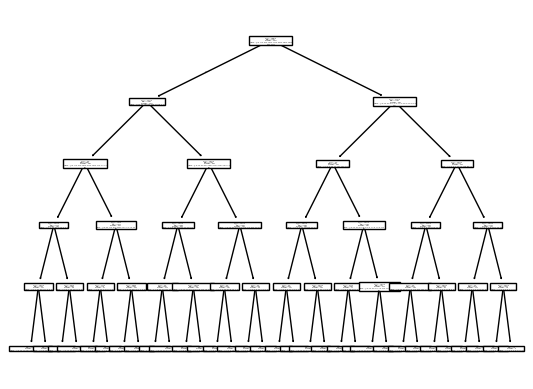

In [9]:
model = DecisionTreeClassifier(max_depth=5)
model = model.fit(X_train, Y_train)
tree.plot_tree(model)
plt.show()

In [10]:
predicted = pd.DataFrame(model.predict(X_test))
predicted = predicted.rename(columns= {0 : 'Prediction'})
predicted
stuff = pd.concat([predicted, Y_test.reset_index()['Overall Qual']], axis=1)
stuff

,Prediction,Overall Qual
0,6,8
1,6,6
2,7,7
3,5,4
4,5,6
...,...,...
435,8,7
436,5,5
437,5,5
438,5,6


In [ ]:
matrix = metrics.confusion_matrix(stuff['Overall Qual'], stuff['Prediction'])
display = metrics.ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=['Yes', "No"])
display.plot()
plt.show()

In [12]:
metrics.accuracy_score(Y_test.reset_index()['Overall Qual'], predicted)

0.5113636363636364

In [13]:
metrics.precision_score(Y_test.reset_index()['Overall Qual'],predicted, average='weighted')

0.4918800915093954

In [14]:
metrics.recall_score(Y_test.reset_index()['Overall Qual'], predicted, average='weighted')

0.5113636363636364

Logboek hier want heb geen zin om excel bestand te maken

In [15]:
logboek = pd.DataFrame([
{
"Feature1": "Year Built",
"Feature2": "Total Bsmt SF",
"Feature3": "Gr Liv Area",
"Accuracy": 0.9340909090909091,
"Precision": 0.9337899543378996,
'Recall': 1.0,
'Max depth' : 3,
'Target' : 'Garage'
},
{
"Feature1": "Year Built",
"Feature2": "Total Bsmt SF",
"Feature3": "Gr Liv Area",
"Accuracy": 0.9295454545454546,
"Precision": 0.9295454545454546,
'Recall': 1.0,
'Max depth' : 1,
'Target' : 'Garage'
},
{
"Feature1": "Year Built",
"Feature2": "Total Bsmt SF",
"Feature3": "Neighborhood",
"Accuracy": 0.9295454545454546,
"Precision": 0.9375,
'Recall': 0.9902200488997555,
'Max depth' : 4,
'Target' : 'Garage'
},
{
"Feature1": "Year Built",
"Feature2": "Total Bsmt SF",
"Feature3": "Neighborhood",
"Accuracy": 0.9295454545454546,
"Precision": 0.9295454545454546,
'Recall': 1.0,
'Max depth' : 2,
'Target' : 'Garage'
},
{
"Feature1": "Year Built",
"Feature2": "Total Bsmt SF",
"Feature3": "Neighborhood",
"Accuracy": 0.9318181818181818,
"Precision": 0.9522673031026253,
'Recall': 0.9755501222493888,
'Max depth' : 10,
'Target' : 'Garage'
},
{
"Feature1": "Year Built",
"Feature2": "Total Bsmt SF",
"Feature3": "Neighborhood",
"Accuracy": 0.5295454545454545,
"Precision": 0.5219361771145893,
'Recall': 0.5295454545454545,
'Max depth' : 10,
'Target' : 'Overall Quall'
},
{
"Feature1": "Year Built",
"Feature2": "House Style",
"Feature3": "Gr Liv Area",
"Accuracy": 0.4954545454545455,
"Precision": 0.4828758779494982,
'Recall': 0.4954545454545455,
'Max depth' : 11,
'Target' : 'Overall Quall'
},
{
"Feature1": "Year Built",
"Feature2": "House Style",
"Feature3": "Gr Liv Area",
"Accuracy": 0.5113636363636364,
"Precision": 0.4918800915093954,
'Recall': 0.5113636363636364,
'Max depth' : 5,
'Target' : 'Overall Quall'
}
])
logboek

,Feature1,Feature2,Feature3,Accuracy,Precision,Recall,Max depth,Target
0,Year Built,Total Bsmt SF,Gr Liv Area,0.934091,0.933790,1.000000,3,Garage
1,Year Built,Total Bsmt SF,Gr Liv Area,0.929545,0.929545,1.000000,1,Garage
2,Year Built,Total Bsmt SF,Neighborhood,0.929545,0.937500,0.990220,4,Garage
3,Year Built,Total Bsmt SF,Neighborhood,0.929545,0.929545,1.000000,2,Garage
4,Year Built,Total Bsmt SF,Neighborhood,0.931818,0.952267,0.975550,10,Garage
5,Year Built,Total Bsmt SF,Neighborhood,0.529545,0.521936,0.529545,10,Overall Quall
6,Year Built,House Style,Gr Liv Area,0.495455,0.482876,0.495455,11,Overall Quall
7,Year Built,House Style,Gr Liv Area,0.511364,0.491880,0.511364,5,Overall Quall


In [16]:
nieuwe_rijen = pd.DataFrame([
{
"Feature1": "",
"Feature2": "",
"Feature3": "",
"Accuracy": 0,
"Precision": 0,
'Recall': 0,
'Max depth' : 0,
'Target' : ''
}
])
#alleen om te copypasten voor hierboven